In [1]:
# #| echo: false
# #| column: margin
# from phasic.utils import download_link
# download_link(__vsc_ipynb_file__) 

---
title: Method of Moments
---

## Data-informed priors via moment matching

A common challenge in Bayesian inference with SVGD is choosing sensible prior distributions. A vague prior may lead to slow convergence or poor exploration of the posterior, while an overly tight prior can bias the result. The `method_of_moments` method provides a principled way to construct data-informed priors by finding parameter estimates that match the model's theoretical moments to the empirical moments of the observed data.

The method solves the nonlinear least-squares problem:

$$
\hat{\theta}_{\text{MoM}} = \arg\min_{\theta > 0} \left\| \mathbf{m}(\theta) - \hat{\mathbf{m}} \right\|^2
$$

where $\mathbf{m}(\theta)$ are the model moments and $\hat{\mathbf{m}}$ are the sample moments computed from the data. The standard error of the estimator is obtained via the delta method:

$$
\text{Cov}(\hat\theta) \;=\; \left(\frac{\partial \mathbf{m}}{\partial \theta}\right)^{-1} \text{Cov}(\hat{\mathbf{m}}) \left(\frac{\partial \mathbf{m}}{\partial \theta}\right)^{-T}
$$

where $\text{Cov}(\hat{\mathbf{m}})$ is estimated from the data. The point estimate and standard error are then used to construct Gaussian priors centred on the MoM estimate.

This is fast (seconds, not minutes) and gives SVGD a much better starting point than a generic prior.

In [2]:
from phasic import (
    Graph, with_ipv, GaussPrior, MoMResult, ProbMatchResult,
    Adam, ExpStepSize, clear_caches,
    StateIndexer, Property,
)
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
np.random.seed(42)
try:
    from vscodenb import set_vscode_theme
    set_vscode_theme()
except ImportError:
    pass
sns.set_palette('tab10')

## Single-parameter model

We start with the simplest case: a single-parameter exponential model. The coalescent rate $\theta$ governs how quickly lineages coalesce. For an exponential distribution, the method of moments has an analytical solution: $\hat{\theta} = 1 / \bar{x}$.

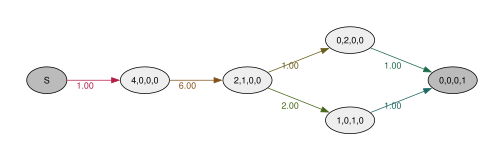

In [3]:
nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent_1param)
graph.plot()

Sample observed data from the model with a known true parameter value:

In [4]:
true_theta = [7]
graph.update_weights(true_theta)
observed_data = graph.sample(1000)

Run method of moments to find the parameter estimate:

In [5]:
mom = graph.method_of_moments(observed_data)

The result is a `MoMResult` dataclass containing the estimate, standard errors, and ready-to-use priors:

In [6]:
print(f"True theta:     {true_theta}")
print(f"MoM estimate:   {mom.theta}")
print(f"Std error:      {mom.std}")
print(f"Converged:      {mom.success}")
print(f"Residual:       {mom.residual:.2e}")

True theta:     [7]
MoM estimate:   [6.92428639]
Std error:      [0.15033634]
Converged:      True
Residual:       3.53e-01


The `MoMResult` also reports how well the model moments match the sample moments:

In [7]:
print(f"Sample moments: {mom.sample_moments}")
print(f"Model moments:  {mom.model_moments}")

Sample moments: [[0.21722891 0.07095162 0.03177163]]
Model moments:  [0.21662882 0.07068175 0.03187847]


## Using MoM estimates as SVGD priors

The main purpose of `method_of_moments` is to produce informed priors for SVGD. The `mom.prior` attribute is a list of `GaussPrior` objects that can be passed directly to `graph.svgd()`:

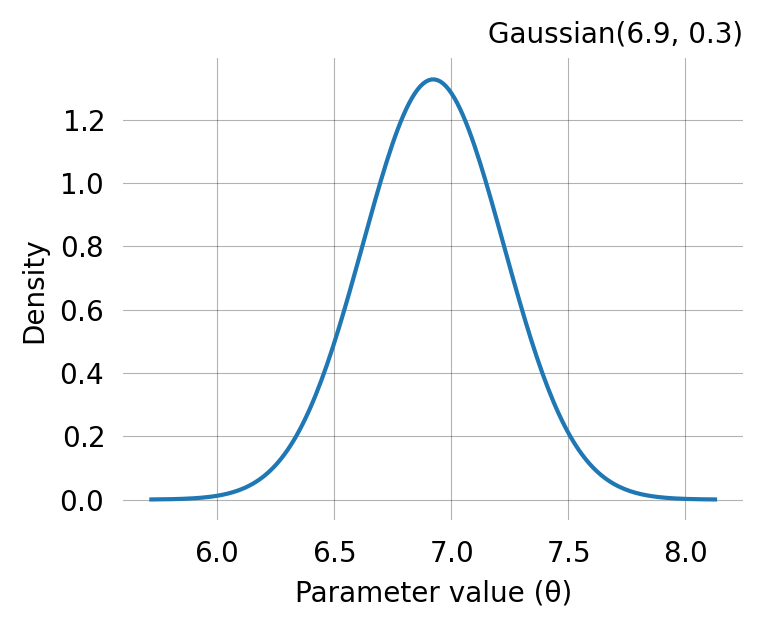

In [10]:
mom.prior[0].plot() ;


Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         6.9315     6.9508     0.2293     6.5170       7.5974      

Particles: 192, Iterations: 200


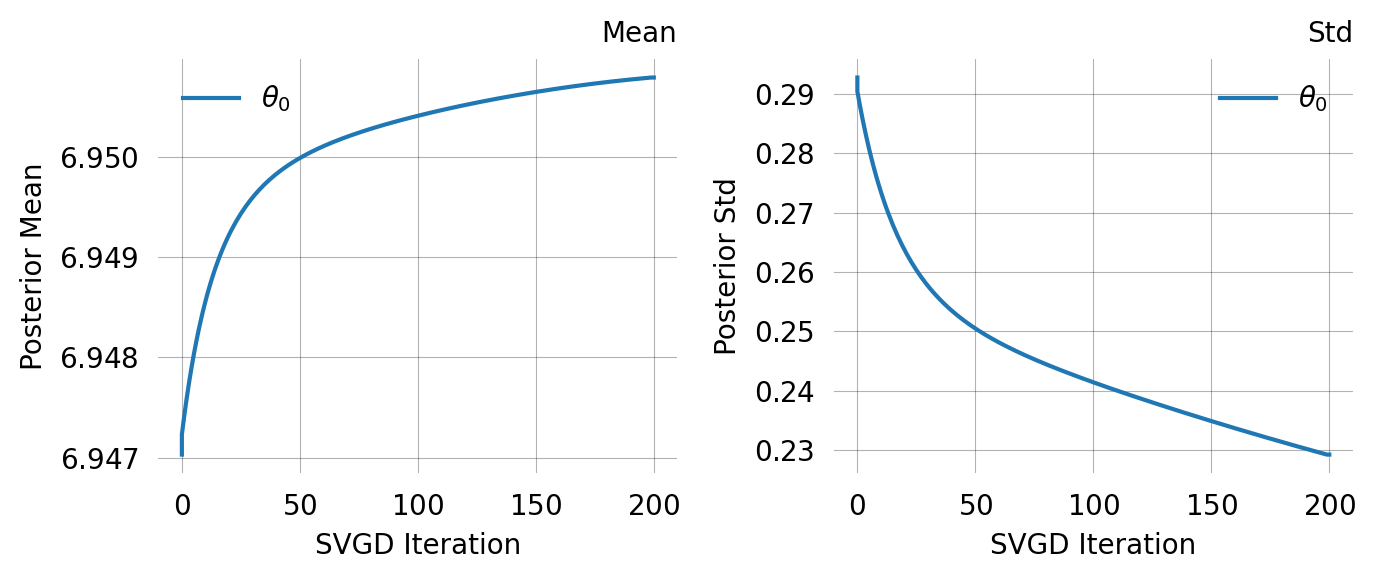

In [17]:
kwargs = dict(
    learning_rate = ExpStepSize(first_step=0.001, last_step=0.0001, tau=20.0),
    n_iterations=200,
)
svgd = graph.svgd(observed_data, prior=mom.prior, **kwargs)
svgd.summary()
svgd.plot_convergence() ;

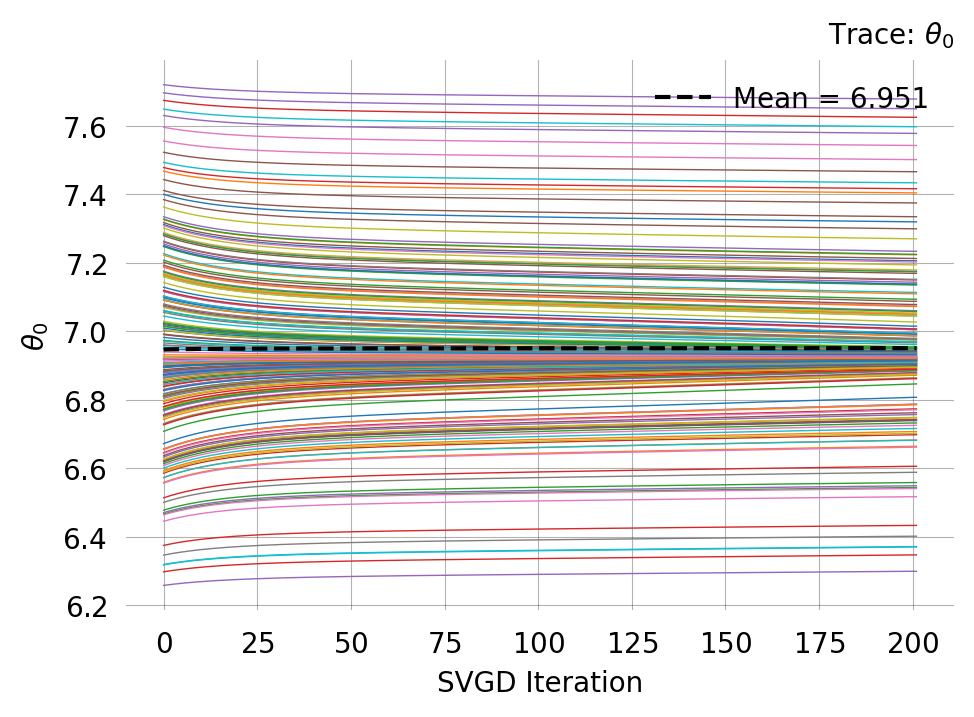

In [18]:
svgd.plot_trace()

Compare this to using a weak prior. The MoM-informed prior starts SVGD in the right region, leading to faster and more reliable convergence:

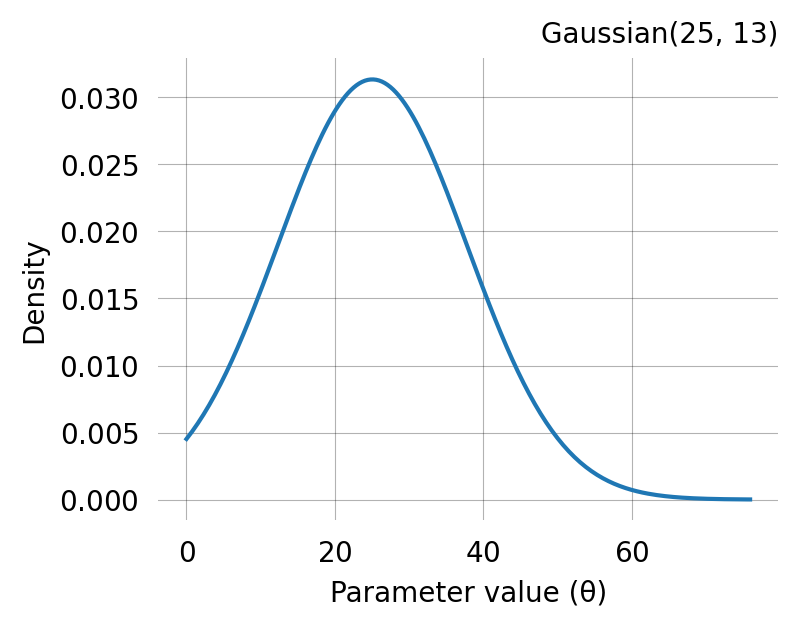

In [19]:
weak_prior = GaussPrior(ci=[0.1, 50])
weak_prior.plot() ;

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         6.8435     23.8304    12.1859    2.6483       47.8080     

Particles: 192, Iterations: 200


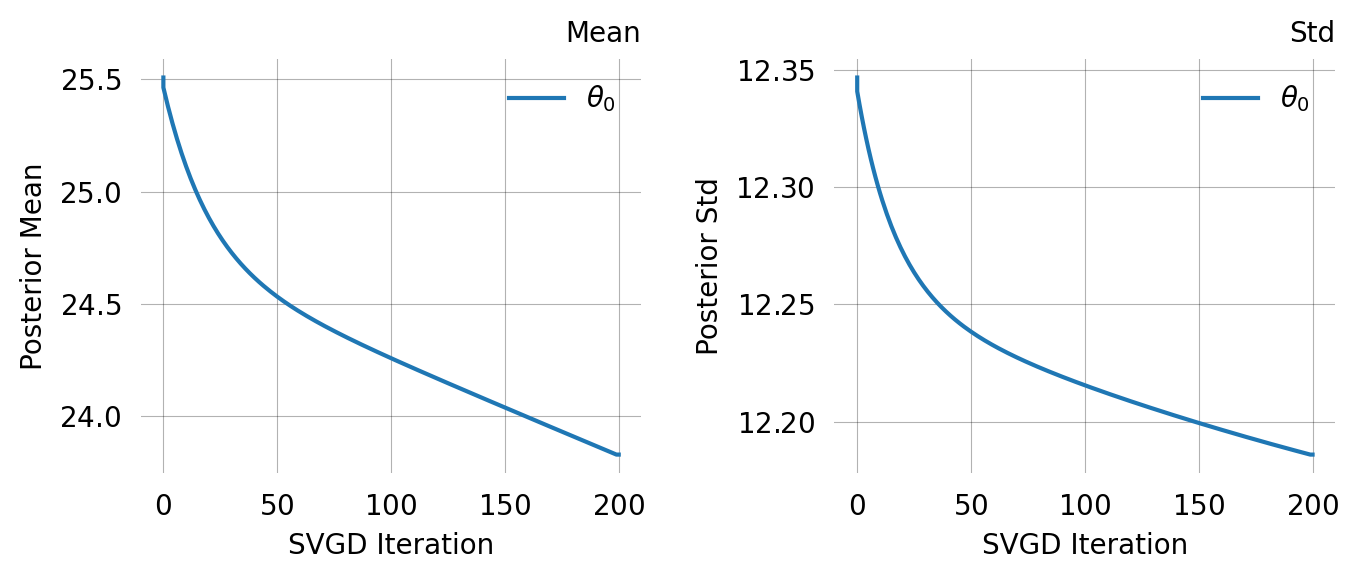

In [ ]:
svgd = graph.svgd(observed_data, prior=weak_prior, **kwargs)
svgd.summary()
svgd.plot_convergence() 
svgd.plot_trace() ;

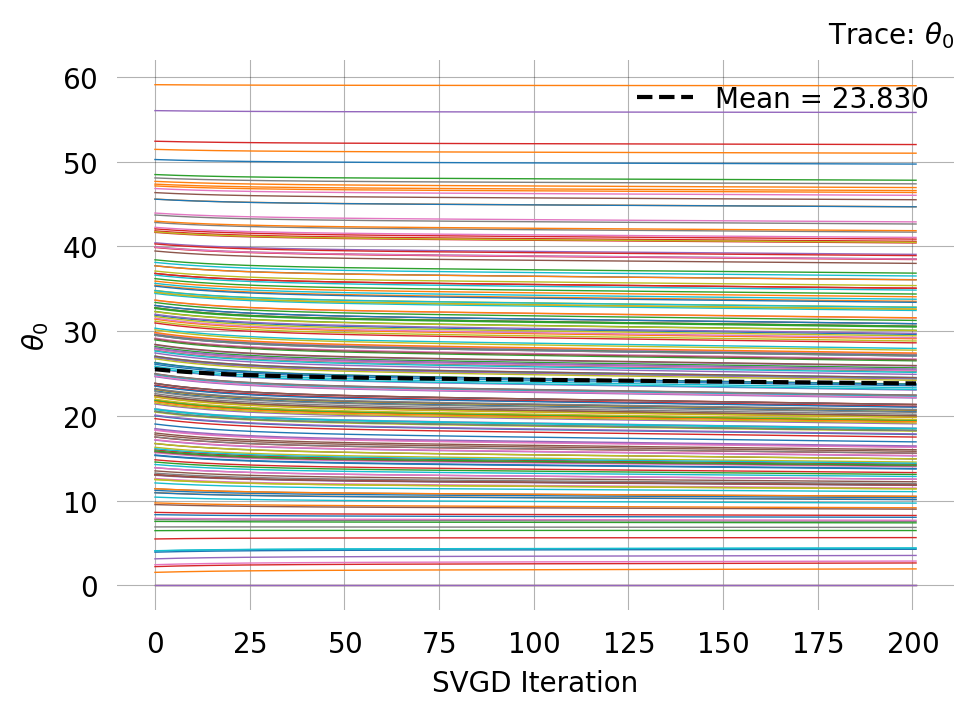

In [21]:
svgd.plot_trace()

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         6.9325     6.9235     0.6272     5.5999       8.0424      

Particles: 192, Iterations: 100


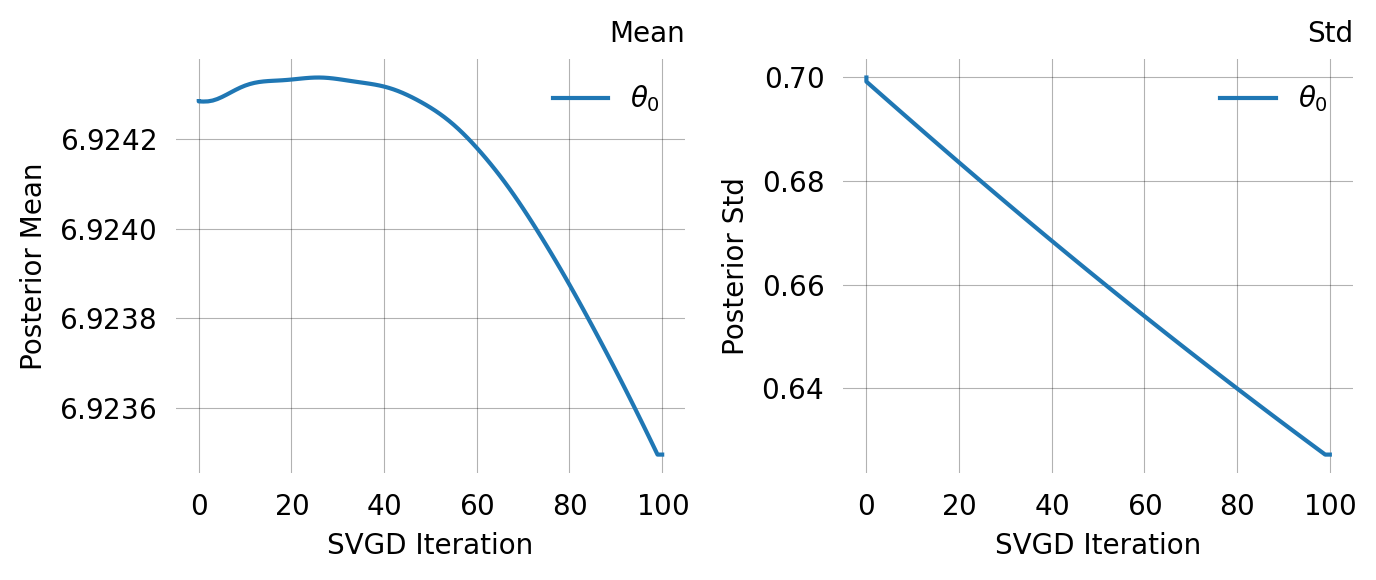

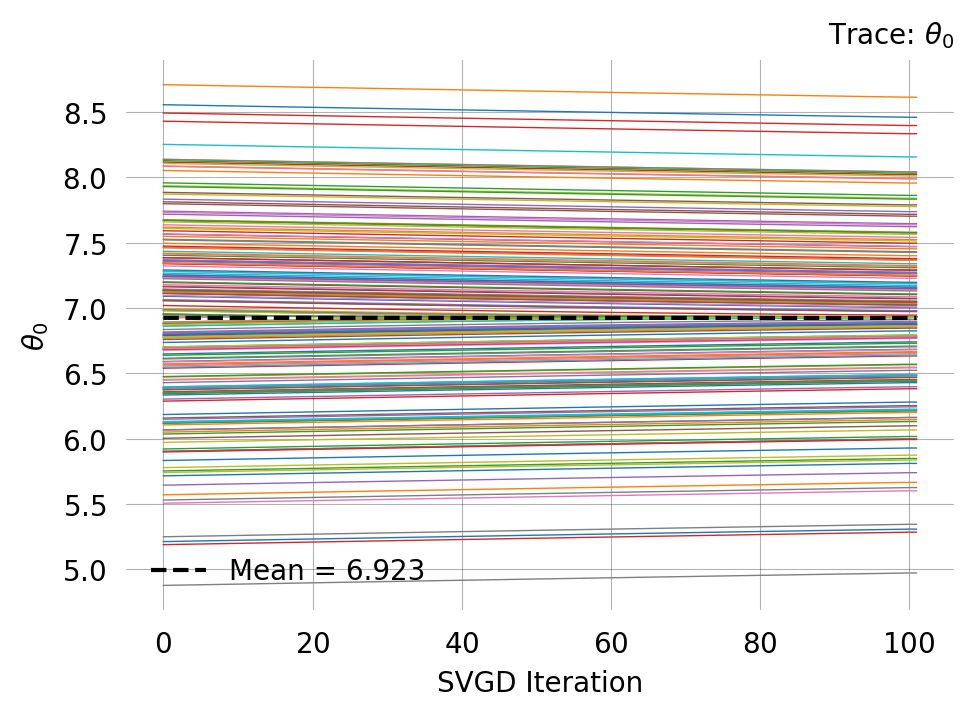

In [24]:
svgd = graph.svgd(observed_data, optimizer=Adam())
svgd.summary()
svgd.plot_convergence()
svgd.plot_trace() ;

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         6.8160     26.7160    12.4619    0.0000       46.0444     

Particles: 192, Iterations: 100


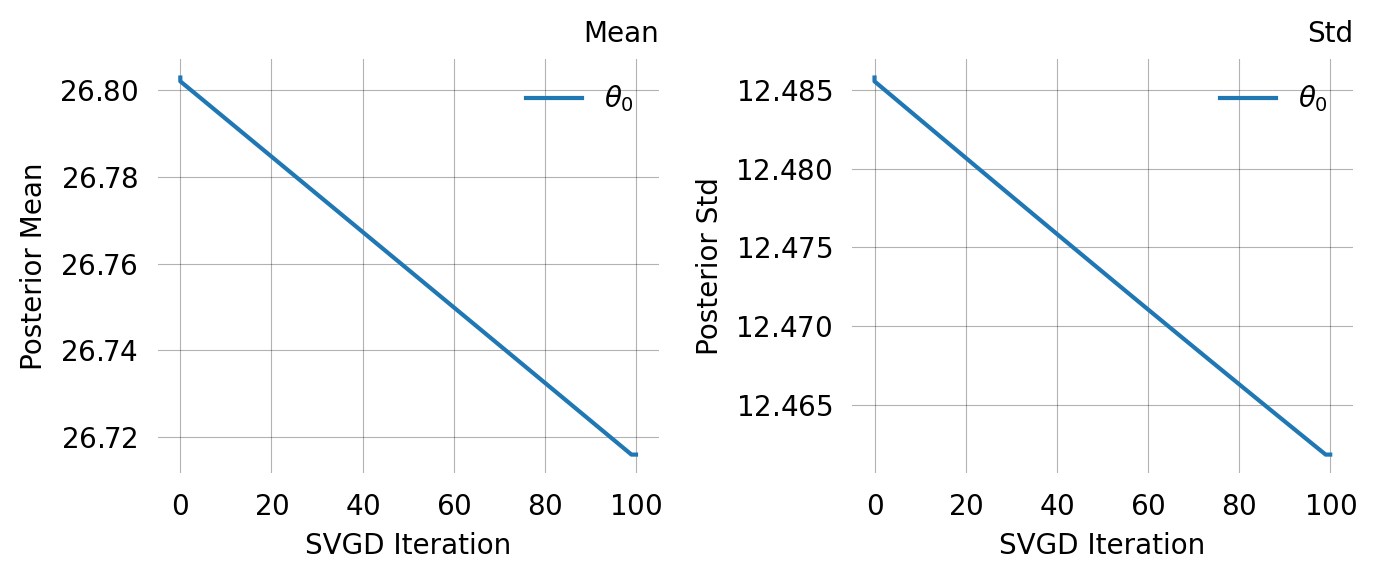

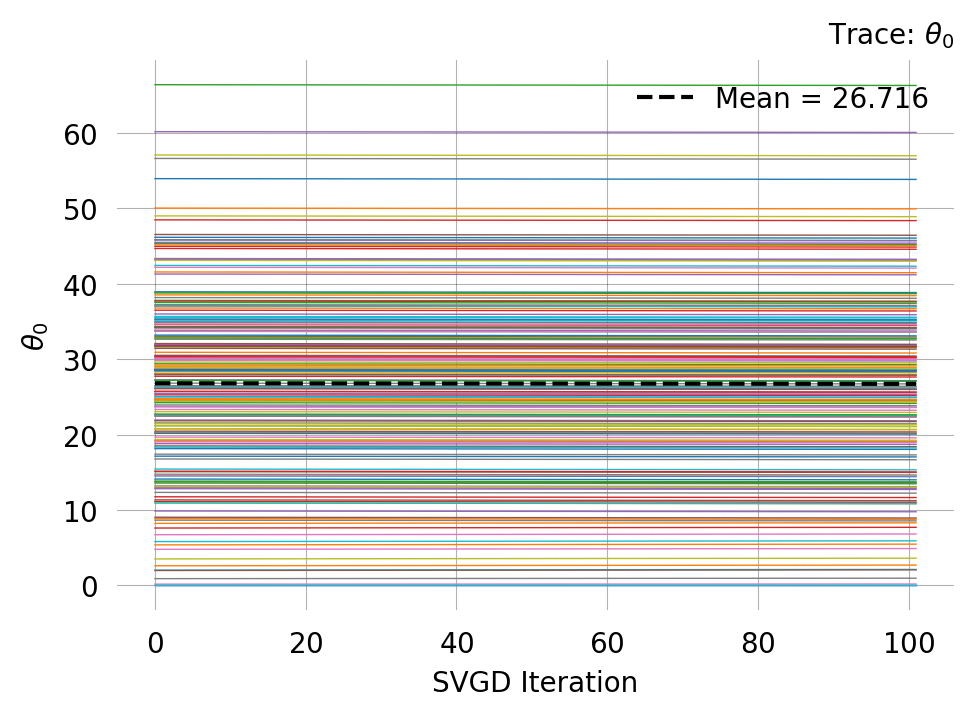

In [25]:
svgd = graph.svgd(observed_data, prior=weak_prior, optimizer=Adam())
svgd.summary()
svgd.plot_convergence()
svgd.plot_trace() ;

## Multi-parameter model

Method of moments is especially useful for multi-parameter models where choosing good priors by hand is difficult. Here we use a two-population island model with coalescent rate $\theta_0$ and migration rate $\theta_1$.

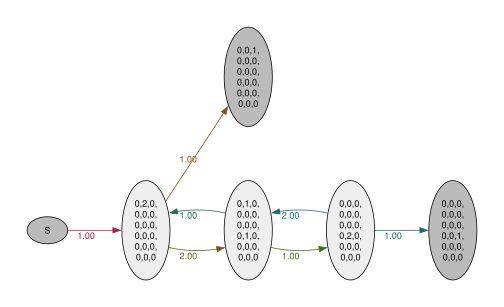

In [26]:
from phasic import StateIndexer, Property

nr_samples = 2

indexer = StateIndexer(
    descendants=[
    Property('pop1', min_value=0, max_value=nr_samples),
    Property('pop2', min_value=0, max_value=nr_samples),
    Property('in_pop', min_value=1, max_value=2),
])

initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial)
def coalescent_islands(state):
    transitions = []
    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)
        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            if props_j.in_pop != props_i.in_pop:
                continue
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            des_pop1 = props_i.pop1 + props_j.pop1
            des_pop2 = props_i.pop2 + props_j.pop2
            if des_pop1 <= nr_samples and des_pop2 <= nr_samples:
                k = indexer.descendants.props_to_index(
                    pop1=des_pop1, pop2=des_pop2, in_pop=props_i.in_pop)
                child[k] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])
        if state[i] > 0:
            child = state.copy()
            other_pop = 2 if props_i.in_pop == 1 else 1
            child[i] -= 1
            k = indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=other_pop)
            child[k] += 1
            transitions.append([child, [0, state[i]]])
    return transitions

graph = Graph(coalescent_islands)
graph.plot()

In [27]:
true_theta = [0.7, 0.9]
graph.update_weights(true_theta)
observed_data = graph.sample(1000)

Run method of moments on the two-parameter model:

In [28]:
mom = graph.method_of_moments(observed_data)

In [29]:
print(f"True theta:     {true_theta}")
print(f"MoM estimate:   {mom.theta}")
print(f"Std error:      {mom.std}")
print(f"Converged:      {mom.success}")

True theta:     [0.7, 0.9]
MoM estimate:   [0.66400525 0.8668053 ]
Std error:      [0.02293177 0.30847508]
Converged:      True


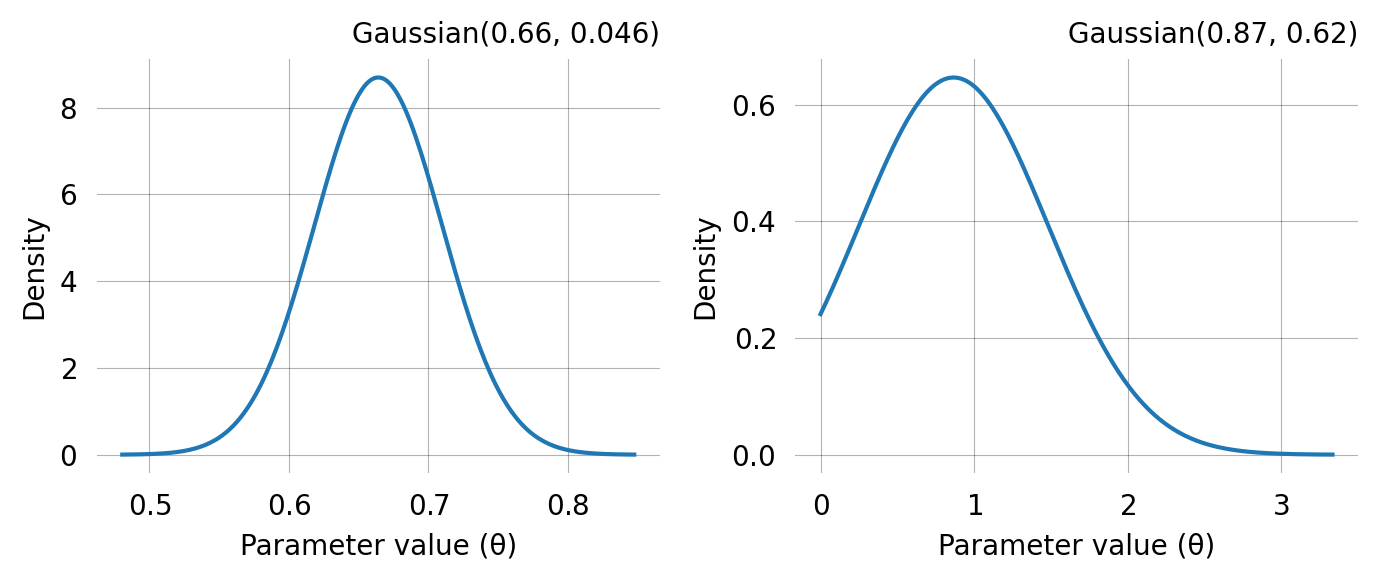

In [36]:
fig, axes = plt.subplots(1, len(mom.prior), figsize=(7,3))
for i, prior in enumerate(mom.prior):
    prior.plot(return_ax=True, ax=axes[i])
plt.tight_layout() ;

Use the MoM priors for SVGD inference:

In [ ]:
svgd = graph.svgd(
    observed_data,
    prior=mom.prior,
    # optimizer=Adam(0.25),
    learning_rate=ExpStepSize(first_step=0.05, last_step=0.005, tau=20.0),
)

In [ ]:
svgd.summary()

In [ ]:
svgd.plot_convergence()

In [ ]:
svgd.plot_pairwise(true_theta=true_theta)

## Fixed parameters

When some parameters are known, you can fix them during moment matching. The `fixed` argument takes a list of `(index, value)` tuples. Only the free parameters are optimised, and the returned `prior` list contains `None` at the fixed positions.

Here we fix the coalescent rate and estimate only the migration rate:

In [ ]:
mom_fixed = graph.method_of_moments(
    observed_data,
    fixed=[(0, 0.7)],  # fix theta[0] (coalescent rate) at 0.7
)

print(f"MoM estimate:  {mom_fixed.theta}")
print(f"Priors:        {mom_fixed.prior}")
print(f"  theta[0] prior is None (fixed): {mom_fixed.prior[0] is None}")
print(f"  theta[1] prior:                 mean={mom_fixed.prior[1].mu:.3f}, std={mom_fixed.prior[1].sigma:.3f}")

The fixed parameter priors integrate seamlessly with SVGD's `fixed` argument:

In [ ]:
svgd_fixed = graph.svgd(
    observed_data,
    prior=mom_fixed.prior,
    fixed=[(0, 0.7)],
    optimizer=Adam(0.25),
)
svgd_fixed.summary()

## Multi-feature observations with rewards

For models where observations are reward-transformed (e.g. branch lengths contributing to different mutation categories in population genetics), method of moments can match moments per feature. Each feature has its own reward vector, and the combined system of equations constrains the parameters.

In [ ]:
graph_1p = Graph(coalescent_1param)
true_theta_1p = [7]
graph_1p.update_weights(true_theta_1p)

# Create reward vectors — each row is a feature's reward across all vertices
states = graph_1p.states().T
rewards = states[:-1]  # one row per feature (e.g. singleton, doubleton, tripleton branch lengths)
print(f"Reward matrix shape: {rewards.shape}  (n_features={rewards.shape[0]}, n_vertices={rewards.shape[1]})")
print(f"Rewards:\n{rewards}")

In [ ]:
# Sample multi-feature observations (each SNP contributes to one feature)
from phasic.svgd import dense_to_sparse


n_obs = 10000
n_features = rewards.shape[0]
observed_data_2d = np.zeros((n_obs * n_features, n_features), dtype=float)
observed_data_2d[:] = np.nan
for i in range(n_features):
    observed_data_2d[(i*n_obs):((i+1)*n_obs), i] = graph_1p.sample(n_obs, rewards=rewards[i])
sparse_data = dense_to_sparse(observed_data_2d)
# np.random.shuffle(observed_data_2d)

# print(f"Observation shape: {observed_data_2d.shape}")
# print(f"First 5 rows (NaN = unobserved feature):")
# print(observed_data_2d[:5])

In [ ]:
mom_multi = graph_1p.method_of_moments(
    sparse_data,
    rewards=rewards,
)

print(f"True theta:     {true_theta_1p}")
print(f"MoM estimate:   {mom_multi.theta}")
print(f"Converged:      {mom_multi.success}")
print(f"\nSample moments (n_features x nr_moments):\n{mom_multi.sample_moments}")
print(f"\nModel moments (n_features x nr_moments):\n{mom_multi.model_moments}")

The multivariate MoM priors can be used with multivariate SVGD:

### FIXME:

In [ ]:
svgd_multi = graph_1p.svgd(
    sparse_data,
    rewards=rewards,
    prior=mom_multi.prior,
    optimizer=Adam(0.25),
)
svgd_multi.summary()
svgd_multi.plot_convergence() ;

## Controlling the number of moments

By default, `method_of_moments` automatically selects the number of moments to create an overdetermined system: `max(2 × n_free_params, 4)` moments per feature. This typically gives robust estimates without any tuning.

You can override the automatic selection by passing `nr_moments` explicitly. If you specify fewer moment equations than free parameters, the method automatically increases `nr_moments`:

## Adjusting the prior width

The `std_multiplier` parameter controls how wide the MoM-derived prior is relative to the asymptotic standard error. A larger multiplier gives a wider, more permissive prior:

In [ ]:
# Default: std_multiplier=2.0
mom_default = graph.method_of_moments(observed_data, verbose=False)
print(f"std_multiplier=2.0 -> prior std = {mom_default.prior[0].sigma:.4f}")

# Wider prior
mom_wide = graph.method_of_moments(observed_data, std_multiplier=5.0, verbose=False)
print(f"std_multiplier=5.0 -> prior std = {mom_wide.prior[0].sigma:.4f}")

# Tighter prior
mom_tight = graph.method_of_moments(observed_data, std_multiplier=1.0, verbose=False)
print(f"std_multiplier=1.0 -> prior std = {mom_tight.prior[0].sigma:.4f}")

::: { .callout-tip }

### Choosing `std_multiplier`

- **2.0** (default): A good balance — wide enough to let the data speak, tight enough to aid convergence.
- **1.0**: Tight prior. Use when you trust the MoM estimate and want fast convergence.
- **3.0–5.0**: Wide prior. Use when you want SVGD to explore broadly, using MoM only as a rough guide.

:::

## The MoMResult object

The `method_of_moments` method returns a `MoMResult` dataclass with the following fields:

| Field | Type | Description |
|-------|------|-------------|
| `theta` | `np.ndarray` | MoM parameter estimate |
| `std` | `np.ndarray` | Standard error of the MoM estimator (delta method) |
| `prior` | `list` | List of `GaussPrior` objects (or `None` for fixed params) |
| `success` | `bool` | Whether the optimisation converged |
| `residual` | `float` | Sum of squared residuals |
| `sample_moments` | `np.ndarray` | Empirical moments from the data |
| `model_moments` | `np.ndarray` | Model moments at the solution |
| `message` | `str` | Solver status message |

The standard errors quantify the *sampling uncertainty* of the MoM estimator — how much `theta` would change with a different random sample of the same size. They are computed via the delta method, propagating the covariance of the sample moments through the moment-matching equations. These errors scale as $1/\sqrt{n}$ with the sample size $n$.

## Complete workflow

Putting it all together, the recommended workflow for inference is:

1. **Build** the parameterized graph
2. **MoM** — get data-informed priors in seconds
3. **SVGD** — run full Bayesian inference with the MoM priors
4. **Diagnose** — check convergence and posterior

In [ ]:
# 1. Build model
graph = Graph(coalescent_islands)

# 2. Method of moments
true_theta = [0.7, 0.3]
graph.update_weights(true_theta)
observations = graph.sample(100)

mom = graph.method_of_moments(observations)

In [ ]:
fig, axes = plt.subplots(len(mom.prior), 1, figsize=(6,4))
for i, prior in enumerate(mom.prior):
    prior.plot(return_ax=True, ax=axes[i])
plt.tight_layout()


In [ ]:
# from phasic import configure
# configure(
#     force_high_precision=True,
#     mpfr_precision_bits=256
# )

# svgd = graph.svgd(
#     observations,
#     prior=mom.prior,
#     learning_rate=ExpStepSize(first_step=0.01, last_step=0.001, tau=20.0),
#     n_iterations=100,
# )

In [ ]:
# svgd.summary()

In [ ]:
# svgd.plot_convergence()

In [ ]:
# svgd.plot_trace()

In [ ]:
# svgd.plot_pairwise(true_theta=true_theta)

In [ ]:
# svgd.plot_hdr()

## Joint probability models

For **joint probability graphs** — created via `graph.joint_prob_graph()` — observations are feature-count tuples (e.g., `[0, 1, 0, 0]`) rather than continuous times. The model outputs a probability table, not a PDF/PMF with moments, so standard moment matching does not apply.

The `probability_matching()` method handles this case by matching the **empirical probability distribution** to the **model probability distribution**:

$$
\hat{\theta}_{\text{PM}} = \arg\min_{\theta > 0} \left\| \mathbf{p}_{\text{model}}(\theta) - \hat{\mathbf{p}} \right\|^2
$$

where $\hat{\mathbf{p}}$ are the empirical proportions of each observation pattern. Standard errors are obtained via the delta method with the multinomial covariance:

$$
\text{Cov}(\hat{p}_i, \hat{p}_j) = \frac{\delta_{ij} p_i - p_i p_j}{n}
$$

In [ ]:
from functools import partial
from itertools import combinations_with_replacement

all_pairs = partial(combinations_with_replacement, r=2)

# Build the coalescent base graph
nr_samples = 3

indexer = StateIndexer(
    lineage=[
        Property('descendants', min_value=1, max_value=nr_samples),
    ]
)

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i, j in all_pairs(indexer.lineage):
        p1 = indexer.lineage.index_to_props(i)
        p2 = indexer.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        descendants = p1.descendants + p2.descendants
        k = indexer.lineage.props_to_index(descendants=descendants)
        new[k] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

base_graph = Graph(coalescent_1param)

# Create joint probability graph
mutation_rate = 1.0
joint_graph = base_graph.joint_prob_graph(
    indexer, tot_reward_limit=2, mutation_rate=mutation_rate
)
joint_graph.joint_prob_table()

Sample observations from the joint probability table:

In [ ]:
true_theta = [7.0, mutation_rate]
joint_graph.update_weights(true_theta)

# Sample from the joint probability table
table = joint_graph.joint_prob_table()
p = table['prob'].to_numpy()
p = p / p.sum()
feature_cols = table.columns[:-1]

np.random.seed(42)
n_obs = 2000
sampled_rows = np.random.choice(len(table), size=n_obs, p=p)
observations = [tuple(int(x) for x in row) for row in table.iloc[sampled_rows][feature_cols].values]
print(f"Sampled {n_obs} observations, first 5: {observations[:5]}")

Run `probability_matching()` with the mutation rate fixed:

In [ ]:
pm = joint_graph.probability_matching(
    observations,
    fixed=[(1, mutation_rate)],
)

print(f"True theta:     {true_theta}")
print(f"PM estimate:    {pm.theta}")
print(f"Std error:      {pm.std}")
print(f"Converged:      {pm.success}")
print(f"Residual:       {pm.residual:.2e}")

The `ProbMatchResult` includes the empirical and model probabilities at the solution:

In [ ]:
import pandas as pd
pd.DataFrame({
    'vertex_index': pm.unique_indices,
    'empirical_prob': pm.empirical_probs,
    'model_prob': pm.model_probs,
})

The `.prior` list can be passed directly to `graph.svgd()`, just like `MoMResult.prior`:

In [ ]:
svgd_jp = joint_graph.svgd(
    observations,
    prior=pm.prior,
    fixed=[(1, mutation_rate)],
    optimizer=Adam(0.25),
)

In [ ]:
svgd_jp.summary()

In [ ]:
svgd_jp.plot_convergence()

## One-step alternative: `DataPrior`

The two-step pattern of running `method_of_moments` (or `probability_matching`) followed by passing `.prior` to `graph.svgd()` is common enough that `DataPrior` wraps it into a single object. It auto-detects whether the graph is a joint probability graph and calls the appropriate estimation method.

```python
# Before (two steps):
mom = graph.method_of_moments(data, fixed=[(1, 1.0)])
svgd = graph.svgd(data, prior=mom.prior, fixed=[(1, 1.0)])

# After (one step):
svgd = graph.svgd(data, prior=DataPrior(graph, data, fixed=[(1, 1.0)]), fixed=[(1, 1.0)])
```

In [ ]:
# from phasic import DataPrior

# # Standard graph — DataPrior calls method_of_moments internally
# graph_dp = Graph(coalescent_islands)
# graph_dp.update_weights([0.7, 0.3])
# data_dp = graph_dp.sample(500)

# dp = DataPrior(graph_dp, data_dp, sd=2.0)
# print(dp)
# print(f"Underlying method: {dp.method}")
# print(f"Theta estimate:    {dp.theta}")
# print(f"Converged:         {dp.success}")

# # Use directly as the prior argument
# svgd_dp = graph_dp.svgd(data_dp, prior=dp, n_iterations=50, verbose=False)
# svgd_dp.summary()

In [ ]:
# # Joint probability graph — DataPrior calls probability_matching internally
# dp_joint = DataPrior(
#     joint_graph, observations,
#     fixed=[(1, mutation_rate)],
# )
# print(dp_joint)
# print(f"Underlying method: {dp_joint.method}")